# Pursuit-Evasion sanity-check walkthrough

1v1 chase scenario where the bandit tries to close on the guard while the guard tries to escape. Reward is zero-sum on relative distance: bandit wants `-|r_g − r_b|`, guard wants `+|r_g − r_b|`. Termination triggers on `max_steps` OR capture (relative distance below `capture_distance_m`).

This notebook builds the scenario, runs a rollout, renders the trajectory, plots the rollout-time diagnostic, and renders the 2D bandit-position reward surface.

For framework deep-dive see `examples/workflow_3d_rtn.ipynb`. For the reward formula and knob reference see `docs/games/pursuit-evasion.md`.

In [1]:
%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from orbital_game import OrbitalGameEnv, rollout
from orbital_game.env.types import BySide
from orbital_game.games import make_pursuit_evasion
from orbital_game.policies import ZeroControl
from orbital_game.viz import (
    plot_pursuit_evasion_diagnostic,
    plot_pursuit_evasion_position_sweep,
    plot_reward_diagnostic,
    plot_reward_position_sweep,
    plot_rollout_panels,
    plot_rollout_rewards,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Build the scenario

`make_pursuit_evasion` takes one game-specific knob (`capture_distance_m`) plus the standard scenario knobs.

In [2]:
cfg = make_pursuit_evasion(
    capture_distance_m=10.0,
    n_guards=1,
    n_bandits=1,
    dt=10.0,
    max_horizon_s=2000.0,
    seed=0,
)
print(f"max_steps:           {cfg.max_steps}")
print(f"capture_distance_m:  {cfg.game.capture_distance_m} m")
print(f"reference orbit:     {cfg.reference_orbit.position_eci[:3]} m")

max_steps:           200
capture_distance_m:  10.0 m
reference orbit:     [7000000.       0.       0.] m


## 2. Construct env and run two rollouts (zero-control, two seeds)

In [3]:
env = OrbitalGameEnv(cfg)
guard_policy = ZeroControl(n_vehicles=cfg.n_guards, action_dim=3)
bandit_policy = ZeroControl(n_vehicles=cfg.n_bandits, action_dim=3)
init_ps = BySide(
    guard=lambda c, s, k: None,
    bandit=lambda c, s, k: None,
)
key1, key2 = jax.random.split(jax.random.PRNGKey(42), 2)
traj1 = rollout(env, BySide(guard=guard_policy, bandit=bandit_policy), init_ps, key1, n_steps=cfg.max_steps)
traj2 = rollout(env, BySide(guard=guard_policy, bandit=bandit_policy), init_ps, key2, n_steps=cfg.max_steps)
print(f"rollout 1 episode return:  {float(traj1.sides.guard.reward.sum()):.2f}")
print(f"rollout 2 episode return:  {float(traj2.sides.guard.reward.sum()):.2f}")

rollout 1 episode return:  313773.67
rollout 2 episode return:  312372.90


## 3. Trajectory + reward over time

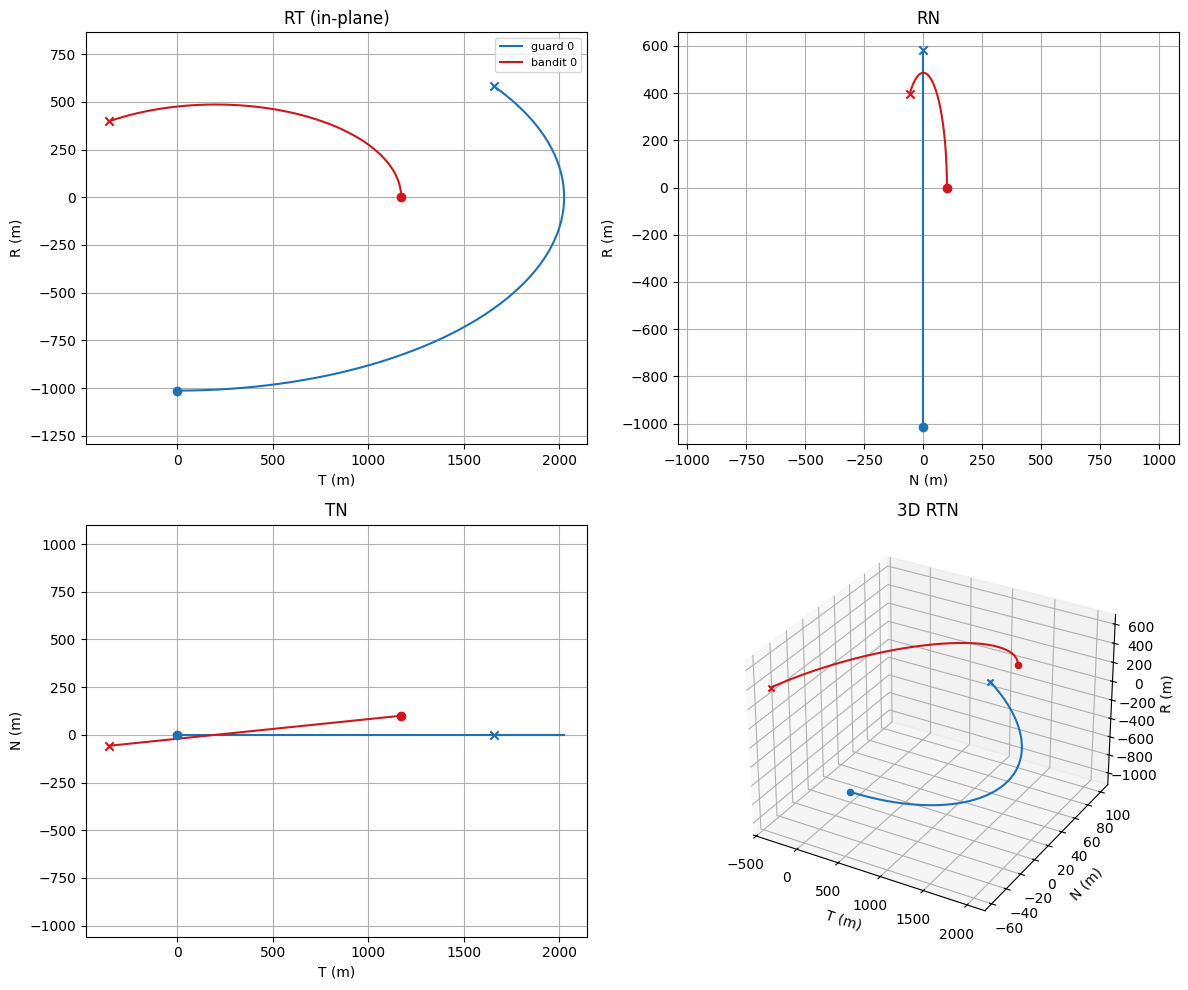

In [4]:
fig = plot_rollout_panels(traj1)
plt.show()

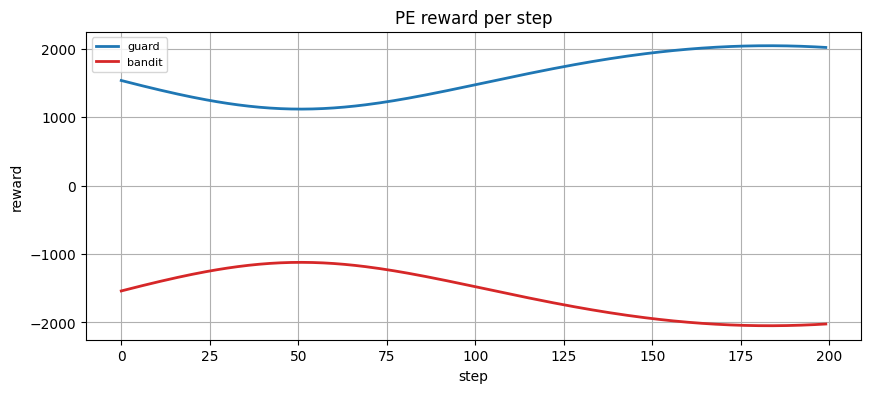

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_rollout_rewards(traj1, ax=ax)
ax.set_title("PE reward per step")
plt.show()

## 4. Game-specific rollout diagnostic

Top panel overlays |guard − bandit| against the capture threshold. Bottom panel shows guard and bandit rewards (zero-sum).

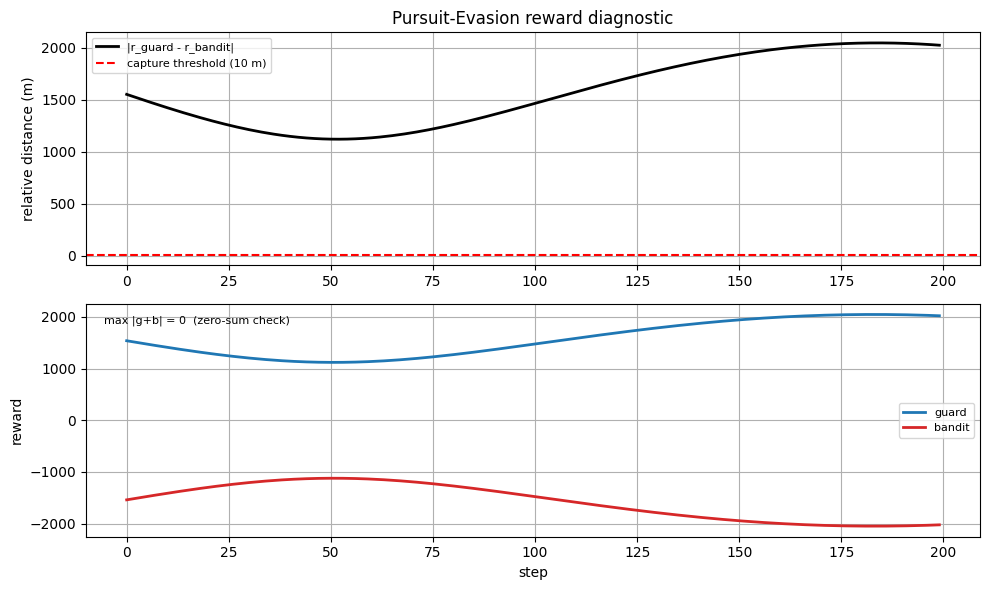

In [6]:
fig = plot_reward_diagnostic(traj1, cfg)
plt.show()

## 5. 2D position-sweep surface

PE reward is `-|guard − bandit|` for the bandit; surface is an inverted cone centered at the guard.

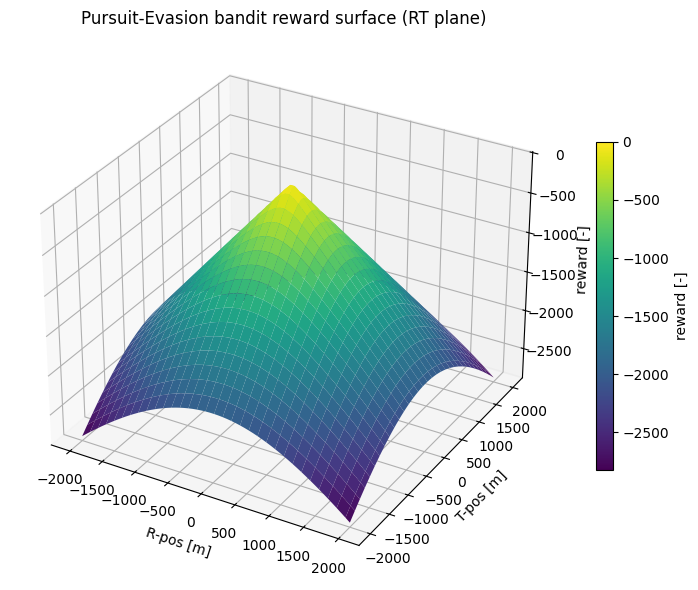

In [7]:
fig = plot_reward_position_sweep(cfg, grid_extent_m=2000.0, grid_steps=64, axis_pair="rt")
plt.show()

## 6. Where to next

- Framework deep-dive: `examples/workflow_3d_rtn.ipynb`
- Game guide: `docs/games/pursuit-evasion.md`
- Other games: `examples/games/lady_bandit_guard.ipynb`, `sun_blocking.ipynb`, `observation_blocking.ipynb`